# Multi-LLM SAC Study — Clean Implementation

Five fully independent cases, each runnable on its own:

| # | Case | Model |
|---|------|-------|
| 0 | **Baseline** | No SAC (plain chunk embedding) |
| 1 | **SAC — Llama 3.1-8B** | `llama-3.1-8b-instant` via Groq |
| 2 | **SAC — Qwen 3-32B** | `qwen/qwen3-32b` via Groq (COT model → strips `<think>`) |
| 3 | **SAC — DeepSeek-R1** | `deepseek-r1-distill-llama-70b` via Groq (COT model → strips `<think>`) |

**Structure per case:**
1. Install / imports
2. Set API keys
3. Load documents & queries
4. FAISS patch
5. Define `SummaryGenerator` (model-specific)
6. Build retriever & index
7. Evaluate
8. Print results

> Run **Setup (Shared)** once, then run whichever case(s) you want.

## ── SETUP (run once) ──────────────────────────────────────────

In [ ]:
# Install dependencies
!pip install groq google-generativeai faiss-cpu sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 58.9 MB/s eta 0:00:00


In [ ]:
# Upload corpus.zip and benchmarks.zip
from google.colab import files
import zipfile, os, json

print("Upload corpus.zip")
uploaded = files.upload()
for fn in uploaded:
    with zipfile.ZipFile(fn) as z:
        z.extractall('cuad')
    print(f"Extracted {fn}")

print("\nUpload benchmarks.zip (or the individual .json files)")
uploaded = files.upload()
for fn in uploaded:
    if fn.endswith('.zip'):
        with zipfile.ZipFile(fn) as z:
            z.extractall('.')
        print(f"Extracted {fn}")

print("\nFiles in working directory:")
#!ls *.json 2>/dev/null; ls MyDrive/ | head -3

Upload corpus.zip


Saving cuad.zip to cuad.zip
Extracted cuad.zip

Upload benchmarks.zip (or the individual .json files)


Saving cuad.json to cuad.json

Files in working directory:


In [ ]:
# ── Shared data loading (documents + queries) ──────────────────
import os, json
from rag_sac_implementation import Document, Query, RAGRetriever, RAGEvaluator

DATASET   = 'cuad'
BENCH_FILE = 'cuad.json'

# Load documents
documents = []
for filename in os.listdir(DATASET):
    fp = os.path.join(DATASET, filename)
    if not os.path.isfile(fp) or not filename.endswith('.txt'):
        continue
    with open(fp, encoding='utf-8') as f:
        content = f.read()
    documents.append(Document(
        doc_id=filename.replace('.txt', ''),
        filename=filename,
        content=content,
        doc_type='cuad'
    ))
print(f"Loaded {len(documents)} documents")

# Load queries
with open(BENCH_FILE) as f:
    bench = json.load(f)
queries = []
for item in bench['tests']:
    if 'snippets' not in item or not item['snippets']:
        continue
    s = item['snippets'][0]
    doc_id = s['file_path'].split('/')[-1].replace('.txt', '')
    start, end = s['span']
    queries.append(Query(
        query_id=str(len(queries)),
        query_text=item['query'],
        ground_truth_doc_id=doc_id,
        ground_truth_start=start,
        ground_truth_end=end
    ))
print(f"Loaded {len(queries)} queries")

TOP_K_VALUES = [1, 2, 4, 8, 16]
evaluator    = RAGEvaluator()
all_results  = {}

Loaded 462 documents
Loaded 4042 queries


In [ ]:
# ── FAISS patch (fixes contiguous-array bug on Colab) ──────────
import numpy as np, faiss
_orig_norm = faiss.normalize_L2
def _fixed_norm(x):
    return _orig_norm(np.ascontiguousarray(x.astype('float32')))
faiss.normalize_L2 = _fixed_norm
print("FAISS patch applied")

FAISS patch applied


In [ ]:
# ── API keys ───────────────────────────────────────────────────
import os
os.environ["GROQ_API_KEY_1"]   = ""
os.environ["GROQ_API_KEY_2"]   = ""
print("Keys set")

Keys set


---
## ── CASE 0 · Baseline (no SAC) ──────────────────────────────

In [ ]:
print("="*60)
print("CASE 0 — Baseline (no SAC)")
print("="*60)

ret_baseline = RAGRetriever(
    embedding_model_name="sentence-transformers/all-MiniLM-L6-v2",
    use_sac=False,
    chunk_size=500,
)
ret_baseline.index_documents(documents)

results_baseline = evaluator.evaluate_dataset(
    queries, ret_baseline, top_k_values=TOP_K_VALUES
)
all_results["Baseline"] = results_baseline
print("Finished: Baseline")

CASE 0 — Baseline (no SAC)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Indexing 462 documents...
Chunking documents...
Created 78378 chunks
Generating embeddings...


Batches:   0%|          | 0/2450 [00:00<?, ?it/s]

Building FAISS index...
Indexing complete!

Evaluating with top_k=1...
  DRM: 15.34%
  Precision: 0.0310
  Recall: 0.0352

Evaluating with top_k=2...
  DRM: 22.23%
  Precision: 0.0324
  Recall: 0.0627

Evaluating with top_k=4...
  DRM: 32.04%
  Precision: 0.0337
  Recall: 0.1049

Evaluating with top_k=8...
  DRM: 41.62%
  Precision: 0.0336
  Recall: 0.1630

Evaluating with top_k=16...
  DRM: 51.32%
  Precision: 0.0324
  Recall: 0.2210
Finished: Baseline


---
## ── CASE 1 · SAC — Llama 3.1-8B (Groq) ─────────────────────

In [ ]:
import os, time, re
from groq import Groq
from rag_sac_implementation import Document

class LlamaSummaryGenerator:
    """
    Llama 3.1-8B-instant via Groq.
    Standard chat model — no CoT, no <think> stripping needed.
    """
    MODEL = "llama-3.3-70b-versatile" #"llama-3.1-8b-instant"

    SYS = ("You are a legal document summarizer. "
           "Produce ONE line under {n} characters. "
           "Include: parties, document type, key obligation, governing law. "
           "Output ONLY the summary, no preamble.")

    USR = ("Summarize this legal document in under {n} characters.\n"
           "Focus on: parties, purpose, key obligations.\n\n"
           "Document:\n{content}\n\nOne line only, under {n} characters:")

    def __init__(self, summary_length=150, max_retries=3, retry_delay=2.0):
        self.n           = summary_length
        self.max_retries = max_retries
        self.retry_delay = retry_delay
        self.api_keys = [
            os.environ.get("GROQ_API_KEY_1"),
            os.environ.get("GROQ_API_KEY_2"),
        ]
        self.current_key_index = 0
        self.client = Groq(api_key=self.api_keys[self.current_key_index])

    def _switch_key(self):
      self.current_key_index = (self.current_key_index + 1) % len(self.api_keys)
      new_key = self.api_keys[self.current_key_index]
      print(f"  🔄 Switching API key → index {self.current_key_index}")
      self.client = Groq(api_key=new_key)
      time.sleep(10)

    def _fallback(self, document):
        sents = re.split(r'[.!?]+', document.content.strip())
        s = ' '.join(x.strip() for x in sents[:2] if x.strip())
        return s[:self.n].strip()

    def generate_summary(self, document):
        snippet = document.content[:3000]
        system  = self.SYS.format(n=self.n)
        user    = self.USR.format(n=self.n, content=snippet)

        for attempt in range(1, self.max_retries + 1):
            try:
                r = self.client.chat.completions.create(
                    model=self.MODEL,
                    messages=[{"role": "system", "content": system},
                               {"role": "user",   "content": user}],
                    temperature=0.2,
                    max_tokens=120,
                    stop=["\n"],
                )
                s = r.choices[0].message.content.strip().strip('"\'')
                s = s[:self.n]
                print(f"  [{document.doc_id[:40]}] {s}")
                return s
            except Exception as e:
                err = str(e).lower()
                if "rate_limit" in err.lower() or "429" in err:
                    print(f"  Rate limit hit on key {self.current_key_index}")
                    if len(self.api_keys) > 1:
                      self._switch_key()
                      continue  # retry immediately with new key
                    wait = self.retry_delay * attempt
                    print(f"  Waiting {wait}s (attempt {attempt})")
                    time.sleep(wait)
                else:
                    print(f"  Groq error: {e}")
                    break

        return self._fallback(document)

    # Aliases expected by RAGRetriever
    def generate_generic_summary(self, doc): return self.generate_summary(doc)
    def generate_expert_summary(self, doc):  return self.generate_summary(doc)


print("LlamaSummaryGenerator defined")

LlamaSummaryGenerator defined


In [ ]:
print("="*60)
print("CASE 1 — SAC with Llama 3.1-8B (Groq)")
print("="*60)

SUMMARY_LENGTH = 150

ret_llama = RAGRetriever(
    embedding_model_name="sentence-transformers/all-MiniLM-L6-v2",
    use_sac=True,
    summary_length=SUMMARY_LENGTH,
    chunk_size=500,
)
ret_llama.summary_generator = LlamaSummaryGenerator(summary_length=SUMMARY_LENGTH)

ret_llama.index_documents(documents)

results_llama = evaluator.evaluate_dataset(
    queries, ret_llama, top_k_values=TOP_K_VALUES
)
all_results["Llama 3.1-8B (Groq)"] = results_llama
print("Finished: Llama")

CASE 1 — SAC with Llama 3.1-8B (Groq)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexing 462 documents...
Generating document summaries...
  [DUOSTECHNOLOGIESGROUP,INC_04_21_2009-EX-] ISA and Rubicon form alliance for software resale and development.
  [FLOTEKINDUSTRIESINCCN_05_09_2019-EX-10.1] FCC and Flotek: supply agreement, FCC to supply terpene products.
  [ReedsInc_20191113_10-Q_EX-10.4_11888303_] Reed's and Full Sail Brewing develop recipes under this agreement.
  [ElPolloLocoHoldingsInc_20200306_10-K_EX-] El Pollo Loco and Developer: franchise development agreement.
  [GRANTIERRAENERGYINC_05_07_2012-EX-10.6-T] Solana, Ecopetrol: transport contract, governed by Colombian law.
  [CnsPharmaceuticalsInc_20200326_8-K_EX-10] CNS and WPD agree on development funding and rights.
  [SFGFINANCIALCORP_05_12_2009-EX-10.1-SOFT] SFG & 551 FX: software license, maintain confidentiality.
  [MIDDLEBROOKPHARMACEUTICALS,INC_03_18_201] MBRK and DD: promotion agreement for MOXATAG.
  [CardlyticsInc_20180112_S-1_EX-10.16_1100] Bank of America and Cardlytics: software license, c

Batches:   0%|          | 0/2450 [00:00<?, ?it/s]

Building FAISS index...
Indexing complete!

Evaluating with top_k=1...
  DRM: 9.30%
  Precision: 0.1054
  Recall: 0.1250

Evaluating with top_k=2...
  DRM: 11.27%
  Precision: 0.0900
  Recall: 0.1881

Evaluating with top_k=4...
  DRM: 13.38%
  Precision: 0.0737
  Recall: 0.2790

Evaluating with top_k=8...
  DRM: 16.43%
  Precision: 0.0549
  Recall: 0.3692

Evaluating with top_k=16...
  DRM: 19.83%
  Precision: 0.0412
  Recall: 0.4759
Finished: Llama


---
## ── CASE 2 · SAC — Qwen 3-32B (Groq, CoT) ─────────────────

In [ ]:
import os, time, re
from groq import Groq
from rag_sac_implementation import Document

class QwenSummaryGenerator:
    """
    Qwen3-32B via Groq.
    This is a reasoning/CoT model: it prefixes its answer with a
    <think>...</think> block.  We strip everything up to and including
    </think> before returning the summary.

    We also pass  include_reasoning=False  to suppress the CoT in the
    response payload (Groq supports this flag for Qwen3).
    """
    MODEL = "qwen/qwen3-32b"

    SYS = ("You are a legal document summarizer. "
           "Produce ONE line under {n} characters. "
           "Include: parties, document type, key obligation, governing law. "
           "Output ONLY the summary, no preamble, no explanation.")

    USR = ("Summarize this legal document in under {n} characters.\n"
           "Focus on: parties, purpose, key obligations.\n\n"
           "Document:\n{content}\n\nOne line only, under {n} characters:")

    def __init__(self, summary_length=150, max_retries=3, retry_delay=2.0):
        self.n           = summary_length
        self.max_retries = max_retries
        self.retry_delay = retry_delay
        self.client      = Groq(api_key=os.environ["GROQ_API_KEY_1"])

    @staticmethod
    def _strip_think(text: str) -> str:
        """Remove <think>...</think> block (may span multiple lines)."""
        # Remove entire <think> block
        text = re.sub(r'<think>[\s\S]*?</think>', '', text, flags=re.IGNORECASE)
        # Also strip any bare <think> prefix that appears without a closing tag
        text = re.sub(r'^\s*<think>.*', '', text, flags=re.IGNORECASE | re.MULTILINE)
        return text.strip()

    def _fallback(self, document):
        sents = re.split(r'[.!?]+', document.content.strip())
        s = ' '.join(x.strip() for x in sents[:2] if x.strip())
        return s[:self.n].strip()

    def generate_summary(self, document):
        snippet = document.content[:3000]
        system  = self.SYS.format(n=self.n)
        user    = self.USR.format(n=self.n, content=snippet)

        for attempt in range(1, self.max_retries + 1):
            try:
                r = self.client.chat.completions.create(
                    model=self.MODEL,
                    messages=[{"role": "system", "content": system},
                               {"role": "user",   "content": user}],
                    temperature=0.2,
                    max_tokens=600,   # extra room for the <think> block
                    # Tell Groq not to return the reasoning tokens in the payload:
                    extra_body={"include_reasoning": False},
                )
                raw = r.choices[0].message.content or ""
                s   = self._strip_think(raw)
                # Take only the first non-empty line
                for line in s.splitlines():
                    line = line.strip().strip('"\'')
                    if line:
                        s = line
                        break
                s = s[:self.n]
                print(f"  [{document.doc_id[:40]}] {s}")
                return s
            except Exception as e:
                err = str(e)
                if "rate_limit" in err.lower() or "429" in err:
                    wait = self.retry_delay * attempt
                    print(f"  Rate limited — waiting {wait}s (attempt {attempt})")
                    time.sleep(wait)
                else:
                    print(f"  Groq error: {e}")
                    break

        return self._fallback(document)

    def generate_generic_summary(self, doc): return self.generate_summary(doc)
    def generate_expert_summary(self, doc):  return self.generate_summary(doc)


print("QwenSummaryGenerator defined")

QwenSummaryGenerator defined


In [ ]:
print("="*60)
print("CASE 2 — SAC with Qwen3-32B (Groq, CoT stripping)")
print("="*60)

SUMMARY_LENGTH = 150

ret_qwen = RAGRetriever(
    embedding_model_name="sentence-transformers/all-MiniLM-L6-v2",
    use_sac=True,
    summary_length=SUMMARY_LENGTH,
    chunk_size=500,
)
ret_qwen.summary_generator = QwenSummaryGenerator(summary_length=SUMMARY_LENGTH)

ret_qwen.index_documents(documents)

results_qwen = evaluator.evaluate_dataset(
    queries, ret_qwen, top_k_values=TOP_K_VALUES
)
all_results["Qwen3-32B (Groq)"] = results_qwen
print("Finished: Qwen")

CASE 2 — SAC with Qwen3-32B (Groq, CoT stripping)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexing 462 documents...
Generating document summaries...
  [DUOSTECHNOLOGIESGROUP,INC_04_21_2009-EX-] ISA and Rubicon enter Strategic Alliance Agreement: ISA as exclusive US agent for Rubicon's products, Rubicon provides software development and consul
  [FLOTEKINDUSTRIESINCCN_05_09_2019-EX-10.1] FCC (DE) and Flotek (OK) enter Supply Agreement for FCC to supply Terpene Product at cost + margin, term until 2023.
  [ReedsInc_20191113_10-Q_EX-10.4_11888303_] 
  [ElPolloLocoHoldingsInc_20200306_10-K_EX-] El Pollo Loco and Developer enter Franchise Development Agreement requiring territory restaurant development, fee payment, governed by California law.
  [GRANTIERRAENERGYINC_05_07_2012-EX-10.6-T] SOLANA PETROLEUM & ECOPETROL S.A. transport crude via OMO/OTA pipelines (USD$0.5192–$3.1143/barrel) under Bogotá-governed contract.
  [CnsPharmaceuticalsInc_20200326_8-K_EX-10] 
  [SFGFINANCIALCORP_05_12_2009-EX-10.1-SOFT] SFG Financial Corp licenses E-Path FX Trading Platform to 551 FX IB Assoc

Batches:   0%|          | 0/2450 [00:00<?, ?it/s]

Building FAISS index...
Indexing complete!

Evaluating with top_k=1...
  DRM: 8.76%
  Precision: 0.1240
  Recall: 0.1477

Evaluating with top_k=2...
  DRM: 10.71%
  Precision: 0.1057
  Recall: 0.2221

Evaluating with top_k=4...
  DRM: 12.72%
  Precision: 0.0805
  Recall: 0.3053

Evaluating with top_k=8...
  DRM: 15.36%
  Precision: 0.0596
  Recall: 0.4020

Evaluating with top_k=16...
  DRM: 18.32%
  Precision: 0.0408
  Recall: 0.4911
Finished: Qwen


---
## ── CASE 3 · SAC — DeepSeek-R1 (Groq, CoT) ─────────────────

In [ ]:
import os, time, re
from groq import Groq
from rag_sac_implementation import Document

class DeepSeekSummaryGenerator:
    """
    DeepSeek-R1-Distill-Llama-70B via Groq.
    Like Qwen3, this is a CoT/reasoning model that wraps its answer in
    <think>...</think>.  We strip the block before returning.

    Available model IDs on Groq (check https://console.groq.com/docs/models):
      - deepseek-r1-distill-llama-70b   (recommended — available as of 2025)
      - deepseek-r1-distill-qwen-32b
    The 8B distillation (deepseek-r1-distill-llama-8b) was removed from Groq.
    """
    MODEL = "deepseek-r1-distill-llama-70b"

    SYS = ("You are a legal document summarizer. "
           "Produce ONE line under {n} characters. "
           "Include: parties, document type, key obligation, governing law. "
           "Output ONLY the summary after your reasoning, no extra text.")

    USR = ("Summarize this legal document in under {n} characters.\n"
           "Focus on: parties, purpose, key obligations.\n\n"
           "Document:\n{content}\n\nOne line only, under {n} characters:")

    def __init__(self, summary_length=150, max_retries=3, retry_delay=2.0):
        self.n           = summary_length
        self.max_retries = max_retries
        self.retry_delay = retry_delay
        self.client      = Groq(api_key=os.environ["GROQ_API_KEY_2"])

    @staticmethod
    def _strip_think(text: str) -> str:
        """Remove <think>...</think> block (may span multiple lines)."""
        text = re.sub(r'<think>[\s\S]*?</think>', '', text, flags=re.IGNORECASE)
        text = re.sub(r'^\s*<think>.*', '', text, flags=re.IGNORECASE | re.MULTILINE)
        return text.strip()

    def _fallback(self, document):
        sents = re.split(r'[.!?]+', document.content.strip())
        s = ' '.join(x.strip() for x in sents[:2] if x.strip())
        return s[:self.n].strip()

    def generate_summary(self, document):
        snippet = document.content[:3000]
        system  = self.SYS.format(n=self.n)
        user    = self.USR.format(n=self.n, content=snippet)

        for attempt in range(1, self.max_retries + 1):
            try:
                r = self.client.chat.completions.create(
                    model=self.MODEL,
                    messages=[{"role": "system", "content": system},
                               {"role": "user",   "content": user}],
                    temperature=0.2,
                    max_tokens=1024,  # DeepSeek-R1 needs room for its <think> block
                )
                raw = r.choices[0].message.content or ""
                s   = self._strip_think(raw)
                # Take only the first non-empty line after stripping
                for line in s.splitlines():
                    line = line.strip().strip('"\'')
                    if line:
                        s = line
                        break
                s = s[:self.n]
                print(f"  [{document.doc_id[:40]}] {s}")
                return s
            except Exception as e:
                err = str(e)
                if "rate_limit" in err.lower() or "429" in err:
                    wait = self.retry_delay * attempt * 4
                    print(f"  Rate limited — waiting {wait}s (attempt {attempt})")
                    time.sleep(wait)
                else:
                    print(f"  Groq error: {e}")
                    break

        return self._fallback(document)

    def generate_generic_summary(self, doc): return self.generate_summary(doc)
    def generate_expert_summary(self, doc):  return self.generate_summary(doc)


print("DeepSeekSummaryGenerator defined")

DeepSeekSummaryGenerator defined


In [ ]:
print("="*60)
print("CASE 3 — SAC with DeepSeek-R1-70B (Groq, CoT stripping)")
print("="*60)

SUMMARY_LENGTH = 150

ret_deepseek = RAGRetriever(
    embedding_model_name="sentence-transformers/all-MiniLM-L6-v2",
    use_sac=True,
    summary_length=SUMMARY_LENGTH,
    chunk_size=500,
)
ret_deepseek.summary_generator = LlamaSummaryGenerator(summary_length=SUMMARY_LENGTH)

ret_deepseek.index_documents(documents)

results_deepseek = evaluator.evaluate_dataset(
    queries, ret_deepseek, top_k_values=TOP_K_VALUES
)
all_results["Llama-3.3-70b-versatile (Groq)"] = results_deepseek
print("Finished: DeepSeek")

CASE 3 — SAC with DeepSeek-R1-70B (Groq, CoT stripping)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexing 462 documents...
Generating document summaries...
  [DUOSTECHNOLOGIESGROUP,INC_04_21_2009-EX-] ISA and Rubicon form alliance for software resale and development.
  [FLOTEKINDUSTRIESINCCN_05_09_2019-EX-10.1] FCC and Flotek: supply agreement for terpene products.
  [ReedsInc_20191113_10-Q_EX-10.4_11888303_] Reed's and Full Sail Brewing develop recipes under this agreement.
  [ElPolloLocoHoldingsInc_20200306_10-K_EX-] El Pollo Loco and Developer: franchise development agreement.
  [GRANTIERRAENERGYINC_05_07_2012-EX-10.6-T] Solana, Ecopetrol: transportation contract, governs crude oil shipping.
  [CnsPharmaceuticalsInc_20200326_8-K_EX-10] CNS and WPD agree to develop products, with CNS funding development.
  [SFGFINANCIALCORP_05_12_2009-EX-10.1-SOFT] SFG & 551 FX: software license, maintain confidentiality.
  [MIDDLEBROOKPHARMACEUTICALS,INC_03_18_201] MBRK and DD: promotion agreement for MOXATAG.
  [CardlyticsInc_20180112_S-1_EX-10.16_1100] Bank of America and Cardlytics: software

Batches:   0%|          | 0/2450 [00:00<?, ?it/s]

Building FAISS index...
Indexing complete!

Evaluating with top_k=1...
  DRM: 14.40%
  Precision: 0.0716
  Recall: 0.0873

Evaluating with top_k=2...
  DRM: 17.00%
  Precision: 0.0648
  Recall: 0.1394

Evaluating with top_k=4...
  DRM: 20.63%
  Precision: 0.0574
  Recall: 0.2122

Evaluating with top_k=8...
  DRM: 24.78%
  Precision: 0.0463
  Recall: 0.2919

Evaluating with top_k=16...
  DRM: 29.79%
  Precision: 0.0374
  Recall: 0.3857
Finished: DeepSeek


---
## ── RESULTS ─────────────────────────────────────────────────

In [4]:
# ── Full results table ─────────────────────────────────────────
TOP_K_VALUES = [1, 2, 4, 8, 16]
method_names = list(all_results.keys())

print("\n" + "="*100)
print("MULTI-LLM SAC STUDY  —  FULL RESULTS")
print("="*100)

for k in TOP_K_VALUES:
    print(f"\n{'='*100}")
    print(f"Top-K = {k}")
    print(f"{'-'*100}")
    print(f"{'Method':<36} {'DRM (%)':>10} {'Precision':>12} {'Recall':>12}")
    print(f"{'-'*100}")
    for name in method_names:
        r = all_results[name][k]
        print(f"{name:<36} {r['drm']:>9.2f}% {r['precision']:>12.4f} {r['recall']:>12.4f}")

print("\n" + "="*100)


MULTI-LLM SAC STUDY  —  FULL RESULTS

Top-K = 1
----------------------------------------------------------------------------------------------------
Method                                  DRM (%)    Precision       Recall
----------------------------------------------------------------------------------------------------
Baseline                                 15.34%       0.0310       0.0352
Llama                                     9.30%       0.1054       0.1250
Qwen                                      8.76%       0.1240       0.1477
DeepSeek                                 14.40%       0.0716       0.0873

Top-K = 2
----------------------------------------------------------------------------------------------------
Method                                  DRM (%)    Precision       Recall
----------------------------------------------------------------------------------------------------
Baseline                                 22.23%       0.0324       0.0627
Llama             

In [5]:
# ── Summary table at k=8 with delta vs Baseline ────────────────
print("\n" + "="*95)
print("FINAL SUMMARY TABLE  (k=8)")
print("="*95)
print(f"{'Method':<36} {'DRM':>8} {'Precision':>10} {'Recall':>10} {'DRM Δ vs Baseline':>22}")
print("-"*95)

base8 = all_results["Baseline"][8]
for name in method_names:
    r    = all_results[name][8]
    drop = base8["drm"] - r["drm"]
    ds   = f"{drop:+.2f} pp" if name != "Baseline" else "reference"
    print(f"{name:<36} {r['drm']:>7.2f}% {r['precision']:>10.4f} {r['recall']:>10.4f} {ds:>22}")

print("="*95)


FINAL SUMMARY TABLE  (k=8)
Method                                    DRM  Precision     Recall      DRM Δ vs Baseline
-----------------------------------------------------------------------------------------------
Baseline                               41.62%     0.0336     0.1630              reference
Llama                                  16.43%     0.0549     0.3692              +25.19 pp
Qwen                                   15.36%     0.0596     0.4020              +26.26 pp
DeepSeek                               24.78%     0.0463     0.2919              +16.84 pp


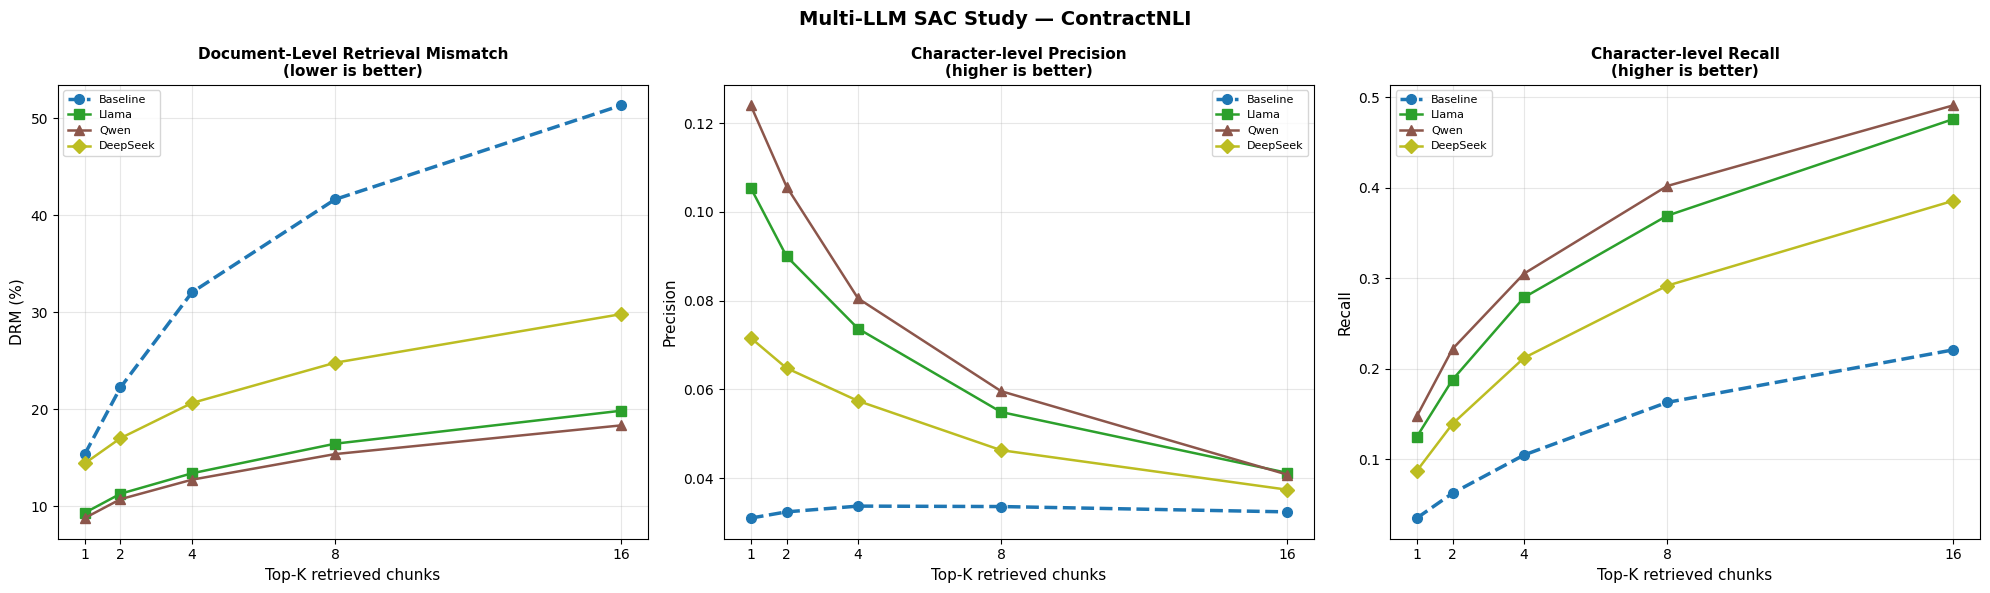

Chart saved to multi_llm_results_cuad.png


In [6]:
# ── Plots ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

k_values     = [1, 2, 4, 8, 16]
method_names = list(all_results.keys())
colours      = plt.cm.tab10(np.linspace(0, 0.8, len(method_names)))
markers      = ["o", "s", "^", "D", "v"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Multi-LLM SAC Study — ContractNLI",
             fontsize=14, fontweight="bold")

panels = [
    ("drm",       "DRM (%)",   axes[0], "Document-Level Retrieval Mismatch\n(lower is better)"),
    ("precision", "Precision", axes[1], "Character-level Precision\n(higher is better)"),
    ("recall",    "Recall",    axes[2], "Character-level Recall\n(higher is better)"),
]

for metric, ylabel, ax, title in panels:
    for i, name in enumerate(method_names):
        vals = [all_results[name][k][metric] for k in k_values]
        ls   = "--" if name == "Baseline" else "-"
        lw   = 2.5  if name == "Baseline" else 1.8
        ax.plot(k_values, vals,
                marker=markers[i % len(markers)],
                color=colours[i], linewidth=lw,
                linestyle=ls, markersize=7, label=name)
    ax.set_xlabel("Top-K retrieved chunks", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticks(k_values)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("multi_llm_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to multi_llm_results_cuad.png")